# Rep 4. Checkpoint 1. Payoff diagrams

Sara y Edgardo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

### **Descargar datos**

In [2]:
# Datos de SPY y opciones
tk  = yf.Ticker('SPY')

# Precio actual del subyacente
S0  = tk.fast_info['last_price']

# Parámetros de la opción
exp = '2026-04-17'
K   = 680

# Cadenas de opciones
calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

# Seleccionar strike 680
row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

# Precio mid (promedio bid-ask)
C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")

S0=634.74  K=680  C=1.1050  P=45.1900


### **Rango de precios**

In [3]:
# Rango de precios posibles al vencimiento
S_range = np.linspace(600, 760, 500)

### **Payoffs brutos y P&L neto de las cuatro posiciones**

In [4]:
# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

### **Payoff diagrams de las cuatro posiciones básicas**

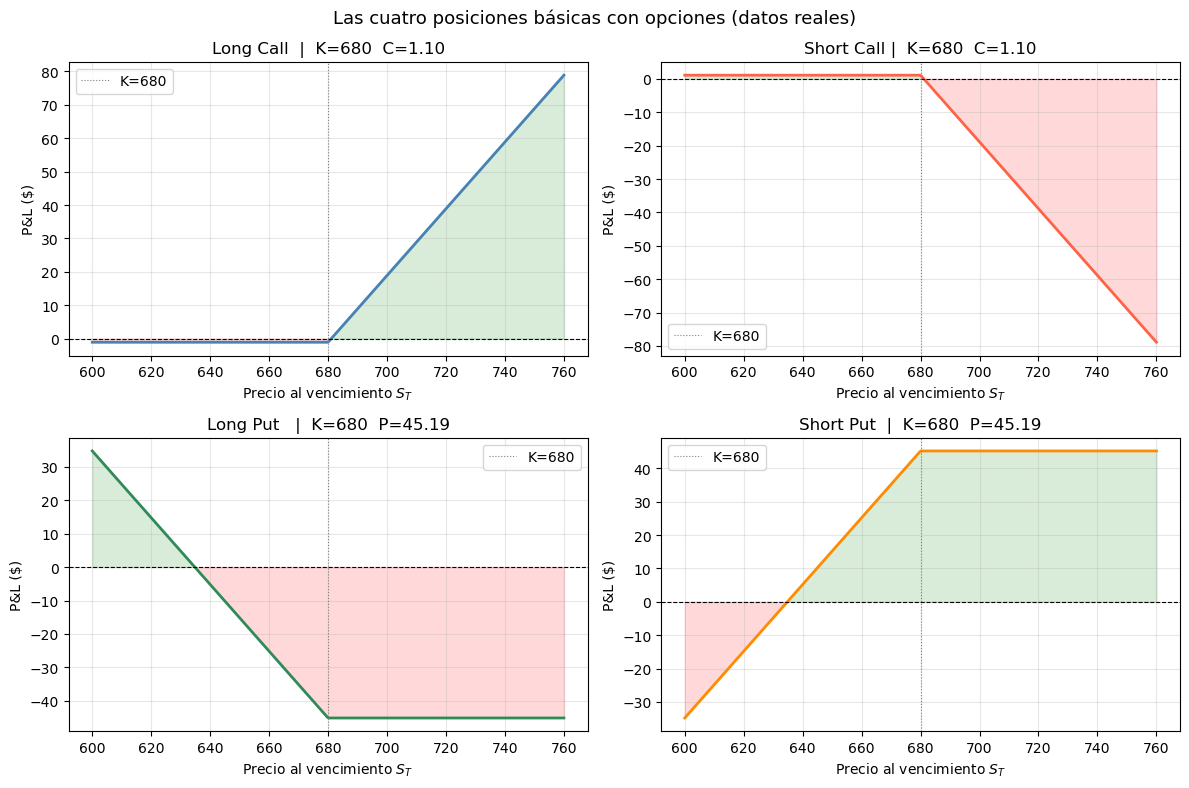

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C:.2f}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call |  K={K}  C={C:.2f}',  'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P:.2f}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P:.2f}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    
    ax.plot(S_range, pnl, color=color, linewidth=2)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray', linewidth=0.8, linestyle=':', label=f'K={K}')
    
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones (datos reales)', fontsize=13)
plt.tight_layout()
plt.show()

### **Comparación Payoff Bruto vs P&L Neto (CALL)**

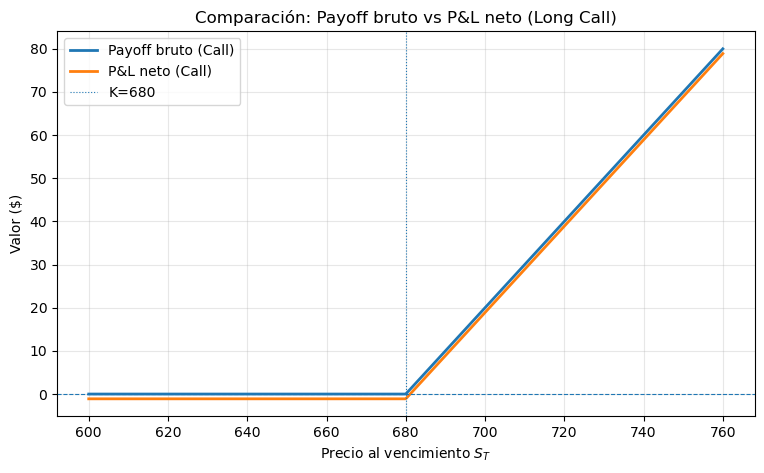

In [6]:
plt.figure(figsize=(9,5))

plt.plot(S_range, call_long_bruto, label='Payoff bruto (Call)', linewidth=2)
plt.plot(S_range, pnl_call_long, label='P&L neto (Call)', linewidth=2)

plt.axhline(0, linestyle='--', linewidth=0.8)
plt.axvline(K, linestyle=':', linewidth=0.8, label=f'K={K}')

plt.xlabel('Precio al vencimiento $S_T$')
plt.ylabel('Valor ($)')
plt.title('Comparación: Payoff bruto vs P&L neto (Long Call)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### **Comparación Payoff Bruto vs P&L Neto (PUT)**

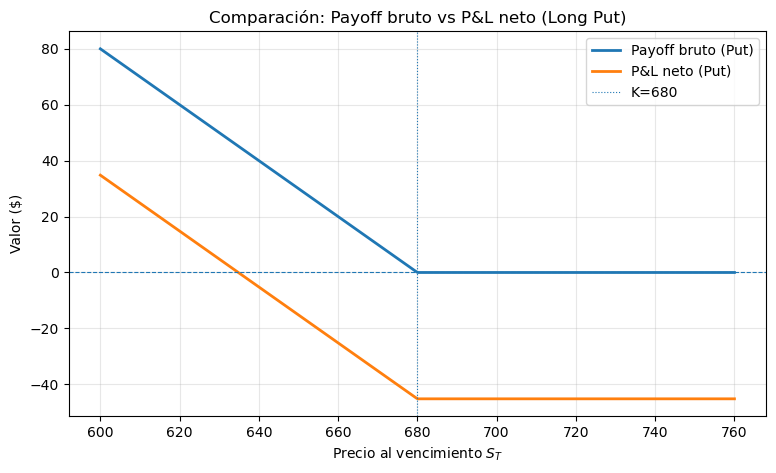

In [7]:
plt.figure(figsize=(9,5))

plt.plot(S_range, put_long_bruto, label='Payoff bruto (Put)', linewidth=2)
plt.plot(S_range, pnl_put_long, label='P&L neto (Put)', linewidth=2)

plt.axhline(0, linestyle='--', linewidth=0.8)
plt.axvline(K, linestyle=':', linewidth=0.8, label=f'K={K}')

plt.xlabel('Precio al vencimiento $S_T$')
plt.ylabel('Valor ($)')
plt.title('Comparación: Payoff bruto vs P&L neto (Long Put)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### **Tabla de break-evens**

In [8]:
# Cálculo de break-evens
be_long_call  = K + C
be_short_call = K + C
be_long_put   = K - P
be_short_put  = K - P

# Crear tabla
tabla_be = pd.DataFrame({
    "Posición": ["Long Call", "Short Call", "Long Put", "Short Put"],
    "Break-even": [be_long_call, be_short_call, be_long_put, be_short_put]
})

tabla_be

,Posición,Break-even
0,Long Call,681.105
1,Short Call,681.105
2,Long Put,634.810
3,Short Put,634.810


## **PREGUNTAS**

**1. Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?**

El precio actual es \(S_0 = 634.74\). Los break-even más cercanos son los de Long Put y Short Put (634.81).  
Esto implica que el precio actual está casi en el punto de equilibrio de estas posiciones, por lo que un pequeño movimiento del mercado puede generar ganancias o pérdidas.

---

**2. Si SPY termina exactamente en \(K\) al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?**

Si \(S_T = K = 680\):

Long Call = -1.105  
Short Call = 1.105  
Long Put = -45.19  
Short Put = 45.19  

Esto ocurre porque las opciones expiran sin valor cuando \(S_T = K\).

---

**3. Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?**

La long call tiene pérdida máxima limitada a la prima pagada (1.105).  
La short put puede tener pérdidas mucho mayores si el precio del activo cae fuertemente.

Por lo tanto, la short put tiene más riesgo.

---

**4. ¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?**

Elegiría una long put cuando espero una caída fuerte del mercado y quiero limitar el riesgo máximo a la prima pagada.